# Classificar o MNIST original

**Autor:** Cleber de Jesus Salustiano  
**Matricula:** 20251mpca0170

## Descricao da Tarefa

Este notebook implementa a classificação do MNIST original, usando `CNNs`.

In [ ]:
import importlib.util
import subprocess
import sys

required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
}

missing_packages = [pkg for module_name, pkg in required_packages.items() if importlib.util.find_spec(module_name) is None]

if missing_packages:
    print(f'Instalando dependencias ausentes: {missing_packages}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])

from pathlib import Path
import gzip
import struct

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8')
torch.manual_seed(42)
np.random.seed(42)


In [2]:
project_root = Path.cwd().resolve()
for candidate in [project_root, *project_root.parents]:
    if (candidate / 'tarefa_cnn_mnist' / 'notebooks').exists():
        project_root = candidate
        break

artifact_root = project_root / 'tarefa_cnn_mnist'
data_dir = artifact_root / 'data' / 'mnist_raw'
data_dir.mkdir(parents=True, exist_ok=True)

MNIST_FILES = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images': 't10k-images-idx3-ubyte.gz',
    'test_labels': 't10k-labels-idx1-ubyte.gz',
}

MNIST_SOURCES = [
    'https://yann.lecun.org/exdb/mnist/',
    'https://ossci-datasets.s3.amazonaws.com/mnist/',
]

print(f'Pasta da tarefa: {artifact_root}')
print(f'Pasta dos dados: {data_dir}')


Pasta da tarefa: /Users/clebersalustiano/Documents/neural-network-master-works/tarefa_cnn_mnist
Pasta dos dados: /Users/clebersalustiano/Documents/neural-network-master-works/tarefa_cnn_mnist/data/mnist_raw


## Download do dataset original

O notebook tenta primeiro a pagina oficial do MNIST de Yann LeCun. Se ela estiver fora do ar, usa um espelho com os mesmos arquivos `IDX` originais.


In [3]:
def download_file(filename: str, destination_dir: Path) -> Path:
    destination = destination_dir / filename
    if destination.exists():
        print(f'Arquivo ja existe: {destination.name}')
        return destination

    last_error = None
    for base_url in MNIST_SOURCES:
        url = base_url + filename
        try:
            print(f'Baixando {url}')
            urllib.request.urlretrieve(url, destination)
            return destination
        except Exception as exc:
            last_error = exc
            if destination.exists():
                destination.unlink()
            print(f'Falha em {url}: {exc}')

    raise RuntimeError(f'Nao foi possivel baixar {filename}') from last_error


def download_mnist_files(destination_dir: Path) -> dict[str, Path]:
    downloaded = {}
    for key, filename in MNIST_FILES.items():
        downloaded[key] = download_file(filename, destination_dir)
    return downloaded


def read_idx_images(path: Path) -> np.ndarray:
    with gzip.open(path, 'rb') as file:
        magic, count, rows, cols = struct.unpack('>IIII', file.read(16))
        if magic != 2051:
            raise ValueError(f'Magic number invalido para imagens: {magic}')
        buffer = file.read()
        images = np.frombuffer(buffer, dtype=np.uint8).copy()
        return images.reshape(count, rows, cols)


def read_idx_labels(path: Path) -> np.ndarray:
    with gzip.open(path, 'rb') as file:
        magic, count = struct.unpack('>II', file.read(8))
        if magic != 2049:
            raise ValueError(f'Magic number invalido para rotulos: {magic}')
        buffer = file.read()
        labels = np.frombuffer(buffer, dtype=np.uint8).copy()
        return labels.reshape(count)


Arquivo ja existe: train-images-idx3-ubyte.gz
Arquivo ja existe: train-labels-idx1-ubyte.gz
Arquivo ja existe: t10k-images-idx3-ubyte.gz
Arquivo ja existe: t10k-labels-idx1-ubyte.gz
Treino: (60000, 28, 28) (60000,)
Teste : (10000, 28, 28) (10000,)


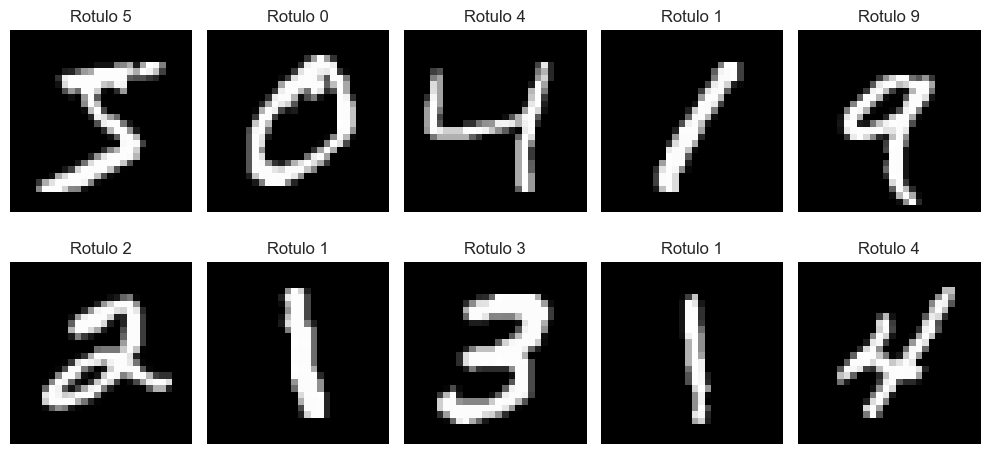

In [4]:
paths = download_mnist_files(data_dir)

train_images = read_idx_images(paths['train_images'])
train_labels = read_idx_labels(paths['train_labels'])
test_images = read_idx_images(paths['test_images'])
test_labels = read_idx_labels(paths['test_labels'])

assert train_images.shape == (60000, 28, 28)
assert train_labels.shape == (60000,)
assert test_images.shape == (10000, 28, 28)
assert test_labels.shape == (10000,)

print('Treino:', train_images.shape, train_labels.shape)
print('Teste :', test_images.shape, test_labels.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), train_images[:10], train_labels[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Rotulo {label}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Preprocessamento manual

Aqui fazemos as etapas que normalmente ficariam escondidas em loaders prontos:

- conversao para `float32`;
- escala para `[0, 1]`;
- inclusao do canal `1 x 28 x 28`;
- divisao treino/validacao;
- normalizacao com media e desvio do treino.


In [5]:
X_full = torch.from_numpy(train_images).float().unsqueeze(1) / 255.0
y_full = torch.from_numpy(train_labels).long()
X_test = torch.from_numpy(test_images).float().unsqueeze(1) / 255.0
y_test = torch.from_numpy(test_labels).long()

validation_size = 10000
permutation = torch.randperm(X_full.size(0))
val_indices = permutation[:validation_size]
train_indices = permutation[validation_size:]

X_train = X_full[train_indices]
y_train = y_full[train_indices]
X_val = X_full[val_indices]
y_val = y_full[val_indices]

train_mean = X_train.mean()
train_std = X_train.std().clamp(min=1e-6)

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False, num_workers=0)

print('Media do treino:', float(train_mean))
print('Desvio do treino:', float(train_std))
print('Train:', tuple(X_train.shape), tuple(y_train.shape))
print('Val  :', tuple(X_val.shape), tuple(y_val.shape))
print('Test :', tuple(X_test.shape), tuple(y_test.shape))


Media do treino: 0.13059958815574646
Desvio do treino: 0.3080507218837738
Train: (50000, 1, 28, 28) (50000,)
Val  : (10000, 1, 28, 28) (10000,)
Test : (10000, 1, 28, 28) (10000,)


In [6]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
)
print('Dispositivo:', device)


class MNISTConvNet(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(inputs))


def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        if training:
            optimizer.zero_grad()

        logits = model(inputs)
        loss = loss_fn(logits, targets)

        if training:
            loss.backward()
            optimizer.step()

        predictions = logits.argmax(dim=1)
        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (predictions == targets).sum().item()
        total_examples += batch_size

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


@torch.no_grad()
def collect_predictions(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    all_targets = []
    all_predictions = []

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        logits = model(inputs)
        loss = loss_fn(logits, targets)
        predictions = logits.argmax(dim=1)

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (predictions == targets).sum().item()
        total_examples += batch_size
        all_targets.append(targets.cpu())
        all_predictions.append(predictions.cpu())

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc, torch.cat(all_targets), torch.cat(all_predictions)


Dispositivo: mps


In [7]:
model = MNISTConvNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, loss_fn, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, loss_fn)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f'Epoca {epoch:02d}/{epochs} | '
        f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} | val_acc={val_acc:.4f}'
    )


Epoca 01/5 | train_loss=0.2204 | train_acc=0.9310 | val_loss=0.0692 | val_acc=0.9781


Epoca 02/5 | train_loss=0.0656 | train_acc=0.9795 | val_loss=0.0446 | val_acc=0.9869


Epoca 03/5 | train_loss=0.0458 | train_acc=0.9864 | val_loss=0.0388 | val_acc=0.9878


Epoca 04/5 | train_loss=0.0376 | train_acc=0.9880 | val_loss=0.0363 | val_acc=0.9903


Epoca 05/5 | train_loss=0.0302 | train_acc=0.9899 | val_loss=0.0297 | val_acc=0.9916


Teste | loss=0.0252 | acc=0.9917


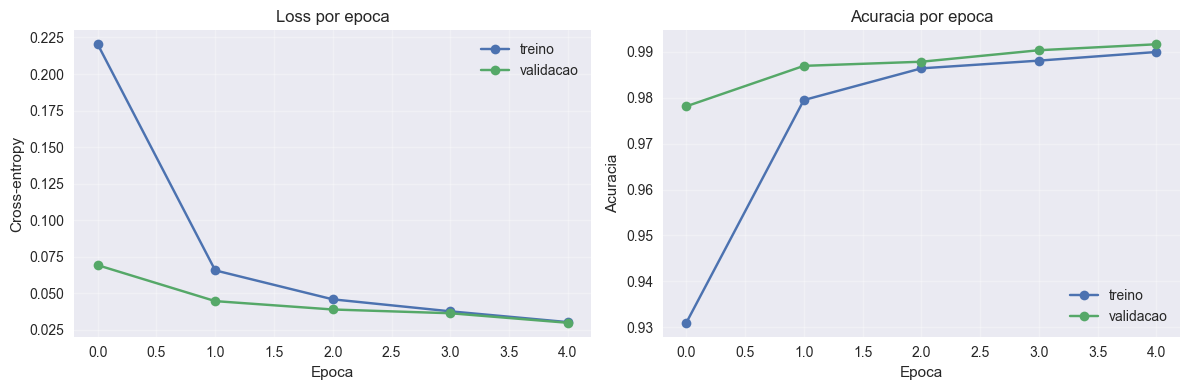

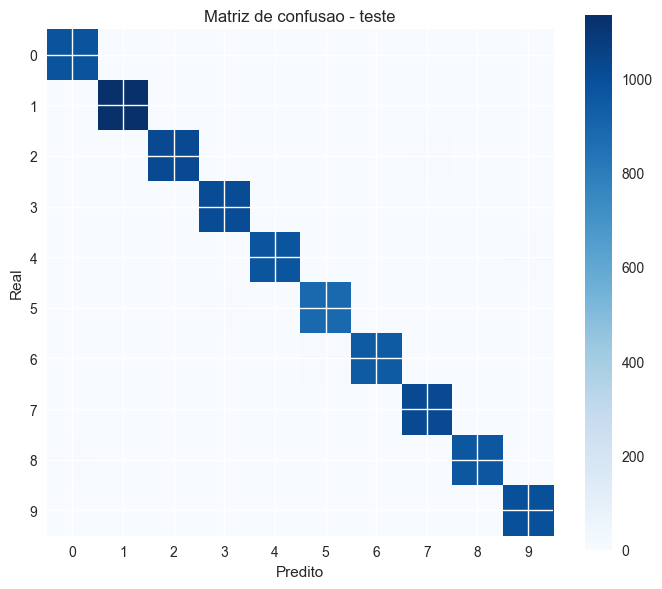

In [8]:
test_loss, test_acc, y_true, y_pred = collect_predictions(model, test_loader, loss_fn)
print(f'Teste | loss={test_loss:.4f} | acc={test_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='treino', marker='o')
axes[0].plot(history['val_loss'], label='validacao', marker='o')
axes[0].set_title('Loss por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross-entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='treino', marker='o')
axes[1].plot(history['val_acc'], label='validacao', marker='o')
axes[1].set_title('Acuracia por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Acuracia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

confusion = torch.zeros((10, 10), dtype=torch.int64)
for target, prediction in zip(y_true, y_pred):
    confusion[target.long(), prediction.long()] += 1

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(confusion.numpy(), cmap='Blues')
ax.set_title('Matriz de confusao - teste')
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


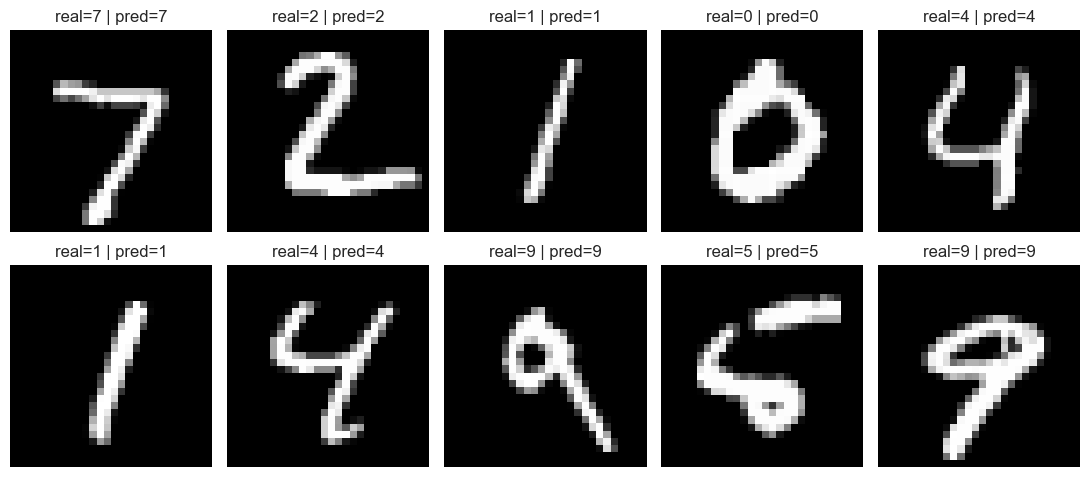

In [9]:
sample_indices = torch.arange(10)
sample_images = test_images[sample_indices.numpy()]
sample_predictions = y_pred[sample_indices].numpy()
sample_targets = y_true[sample_indices].numpy()

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, image, target, prediction in zip(axes.ravel(), sample_images, sample_targets, sample_predictions):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'real={target} | pred={prediction}')
    ax.axis('off')

plt.tight_layout()
plt.show()
